In [1]:
import pandas as pd
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/var/folders/pd/q9m5ptyn78118znr2yc_jql40000gn/T/ipykernel_52469/572529936.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [3]:
# Question 1

df['code_commune'] = (
    df['code_departement'].astype(str) +
    df['code_commune'].astype(str).str.zfill(3)
    )

df['candidat'] = ( df['nom'] +' '+ df['prenom'])

df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,ARTHAUD Nathalie
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,ARTHAUD Nathalie
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,ARTHAUD Nathalie
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,ARTHAUD Nathalie
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,ARTHAUD Nathalie


In [4]:
# Question 2
df['candidat'].value_counts()

candidats = df['candidat'].nunique()

print( f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


In [7]:
# Question 3

results = df.groupby("candidat")["voix"].sum().reset_index()
total_voix = results["voix"].sum()
results["score (%)"] = (results["voix"] / total_voix) * 100
results = results.sort_values(by="voix", ascending=False)

results

,candidat,voix,score (%)
6,MACRON Emmanuel,9783058,27.845822
5,LE PEN Marine,8133828,23.151568
7,MÉLENCHON Jean-Luc,7712520,21.952386
11,ZEMMOUR Éric,2485226,7.073776
9,PÉCRESSE Valérie,1679001,4.778993
3,JADOT Yannick,1627853,4.633409
4,LASSALLE Jean,1101387,3.134912
10,ROUSSEL Fabien,802422,2.283959
1,DUPONT-AIGNAN Nicolas,725176,2.064091
2,HIDALGO Anne,616478,1.754701


In [8]:
!pip install great_tables

Defaulting to user installation because normal site-packages is not writeable


In [9]:
# Question 3
from great_tables import GT

result2 = (
    df.groupby("candidat", as_index=False)["voix"]
    .sum()
    .sort_values(by="voix", ascending=False)
)

total_voix = result2["voix"].sum()
result2["score (%)"] = (result2["voix"] / total_voix) * 100

# 2. Création du tableau GT
table = (
    GT(result2)
    .tab_header(
        title="Résultats du premier tour",
    )
    .cols_label(
        candidat="Candidat",
        voix="Nombre votes (total)",
        **{"score (%)": "Score (% votes exprimés)"}
    )
    .fmt_number(
        columns="voix",
        decimals=0,
        use_seps=True
    )
    .fmt_number(
        columns="score (%)",
        decimals=2
    )
)

table


GT(_tbl_data=                 candidat     voix  score (%)
6         MACRON Emmanuel  9783058  27.845822
5           LE PEN Marine  8133828  23.151568
7      MÉLENCHON Jean-Luc  7712520  21.952386
11           ZEMMOUR Éric  2485226   7.073776
9        PÉCRESSE Valérie  1679001   4.778993
3           JADOT Yannick  1627853   4.633409
4           LASSALLE Jean  1101387   3.134912
10         ROUSSEL Fabien   802422   2.283959
1   DUPONT-AIGNAN Nicolas   725176   2.064091
2            HIDALGO Anne   616478   1.754701
8         POUTOU Philippe   268904   0.765390
0        ARTHAUD Nathalie   197094   0.560995, _body=<great_tables._gt_data.Body object at 0x115b4c2e0>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x115b59490>, _spanners=Spanners([]), _heading=Heading(title='Résultats du premier tour', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x115b4cfa0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x115b4cf70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x115b4c460>, _formats=[<great_tables._gt_data.FormatInfo object at 0x115b4c040>, <great_tables._gt_data.FormatInfo object at 0x115b4c0d0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='ta

In [10]:
# On retire les abstentions, blancs et nuls
df_votes = df[~df["candidat"].isin(["Abstentions", "Blancs", "Nuls"])].copy()

# Total des voix par département et par candidat
score_departements = (
    df_votes
    .groupby(["code_departement", "candidat"], as_index=False)["voix"]
    .sum()
    .rename(columns={"voix": "votes"})
)

# Total des votes exprimés par département
totaux_departement = (
    score_departements
    .groupby("code_departement", as_index=False)["votes"]
    .sum()
    .rename(columns={"votes": "total_votes_departement"})
)

# Ajout du total départemental et calcul du score en pourcentage
score_departements = score_departements.merge(totaux_departement, on="code_departement")
score_departements["score"] = (
    score_departements["votes"] / score_departements["total_votes_departement"] * 100
).round(2)

# Tri final
score_departements = score_departements.sort_values(
    by=["code_departement", "votes"],
    ascending=[True, False]
).reset_index(drop=True)

# Affichage du résultat
score_departements.head(20)


,code_departement,candidat,votes,total_votes_departement,score
0,01,MACRON Emmanuel,92206,333024,27.69
1,01,LE PEN Marine,86755,333024,26.05
2,01,MÉLENCHON Jean-Luc,57832,333024,17.37
3,01,ZEMMOUR Éric,27530,333024,8.27
4,01,PÉCRESSE Valérie,17572,333024,5.28
5,01,JADOT Yannick,15843,333024,4.76
6,01,LASSALLE Jean,10876,333024,3.27
7,01,DUPONT-AIGNAN Nicolas,8998,333024,2.70
8,01,ROUSSEL Fabien,5938,333024,1.78
9,01,HIDALGO Anne,5644,333024,1.69


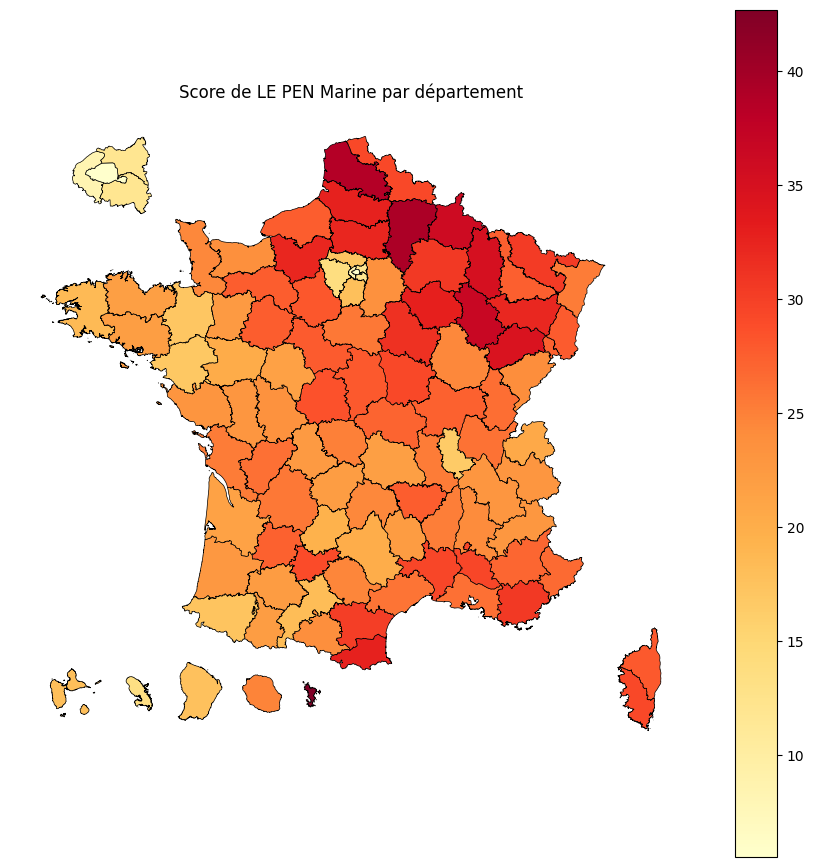

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def cartographier_candidat(score_departements, departement_borders, nom_candidat):
    # Copie des données
    df_score = score_departements.copy()
    df_carte = departement_borders.copy()

    # Normalisation des codes département
    def normaliser_code_dep(serie):
        return (
            serie.astype(str)
            .str.strip()
            .str.upper()
            .str.replace(".0", "", regex=False)
            .str.replace(r"\s+", "", regex=True)
            .str.replace(r"[^0-9A-Z]", "", regex=True)
        )

    # Filtre candidat
    candidat_filtre = df_score[
        df_score["candidat"].astype(str).str.strip().str.upper() == nom_candidat.strip().upper()
    ].copy()

    if candidat_filtre.empty:
        raise ValueError("Aucune ligne trouvée pour ce candidat")

    candidat_filtre["code_departement"] = normaliser_code_dep(candidat_filtre["code_departement"])

    # Détection automatique de la colonne code du fond de carte
    meilleure_colonne = None
    meilleur_nb_matchs = -1

    for col in df_carte.columns:
        if col == "geometry":
            continue

        try:
            valeurs_carte = normaliser_code_dep(df_carte[col])
            nb_matchs = valeurs_carte.isin(candidat_filtre["code_departement"]).sum()

            if nb_matchs > meilleur_nb_matchs:
                meilleur_nb_matchs = nb_matchs
                meilleure_colonne = col
        except Exception:
            pass

    # Si aucune colonne ne marche, on essaie l'index
    if meilleur_nb_matchs == 0:
        valeurs_index = normaliser_code_dep(pd.Series(df_carte.index, index=df_carte.index))
        nb_matchs_index = valeurs_index.isin(candidat_filtre["code_departement"]).sum()

        if nb_matchs_index > meilleur_nb_matchs:
            df_carte = df_carte.reset_index().rename(columns={"index": "code_dep_index"})
            meilleure_colonne = "code_dep_index"
            meilleur_nb_matchs = nb_matchs_index

    if meilleure_colonne is None or meilleur_nb_matchs == 0:
        raise ValueError("Aucune colonne compatible trouvée pour les codes département")

    df_carte["code_departement"] = normaliser_code_dep(df_carte[meilleure_colonne])

    # Jointure
    carte_finale = df_carte.merge(
        candidat_filtre[["code_departement", "candidat", "votes", "score"]],
        on="code_departement",
        how="left"
    )

    # Carte
    fig, ax = plt.subplots(figsize=(11, 11))
    carte_finale.plot(
        column="score",
        cmap="YlOrRd",
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Pas de données"}
    )

    ax.set_title(f"Score de {nom_candidat} par département")
    ax.axis("off")
    plt.show()

    return carte_finale

carte_marine = cartographier_candidat(score_departements, departement_borders, "LE PEN Marine")
